# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/1/1-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.13.15 | numpy 2.1.3


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [4]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        "dtype": str(arr.dtype),
        "shape": arr.shape,
        "ndim": arr.ndim,
        "size": arr.size,
        "nbytes": arr.nbytes,
    }

In [5]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [8]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The body below is the broken version. Fix it.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle

In [9]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [10]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    col_means = matrix.mean(axis=0)
    col_stds = matrix.std(axis=0)
    return (matrix - col_means) / col_stds

In [11]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [12]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": matrix.sum(),
    }

In [13]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [15]:
# Space# Code to execute and print the required shapes
s_all = _tall.sum()
s_axis0 = _tall.sum(axis=0)
s_axis1 = _tall.sum(axis=1)

print(f"_tall.sum() shape:       {np.shape(s_all)}")
print(f"_tall.sum(axis=0) shape: {s_axis0.shape}")
print(f"_tall.sum(axis=1) shape: {s_axis1.shape}")
print(f"_tall: {_tall}")

_tall.sum() shape:       ()
_tall.sum(axis=0) shape: (4,)
_tall.sum(axis=1) shape: (50,)
_tall: [[ 0.37363034 -1.76221926  0.09016388  0.7933188 ]
 [ 0.33179397 -1.29155279 -0.03014099 -1.10025715]
 [-1.42828327  1.59499842  0.0635967  -0.07228613]
 [-0.27317525  0.84757055 -1.07010448  0.72532867]
 [-0.29414864 -1.6608811   0.22247281  1.33120786]
 [ 1.65720372  0.89159894 -0.75261629 -0.68972198]
 [ 0.07146566 -0.19747213  2.0141257   1.01678372]
 [-0.37492717 -0.31961026  1.72728596 -0.01827261]
 [-0.7531111   1.27077283 -0.44670022  1.04725876]
 [-1.37217732 -0.07455283 -1.16264231 -0.87437289]
 [ 0.06135553  0.95138984  0.42110041 -0.61716621]
 [ 0.97795939  2.07596695 -0.34347735  0.81469733]
 [-0.94498101 -1.17406219  1.29841801 -0.98857956]
 [ 0.99288616 -0.90474284  2.41018063 -0.66676125]
 [-0.61204982 -1.77669893 -1.05745138 -0.57942985]
 [-0.49543244 -1.56913772  0.82001052 -1.18501315]
 [ 1.44820887  0.51333063 -0.94416259  0.42880368]
 [ 1.2949775  -0.72589934  0.870346  

**Your answer:**

When you pass axis=0 to a NumPy reduction method like .sum() or .mean(), you are instructing NumPy to collapse across the rows (the first dimension).

Since _tall has 50 rows and 4 columns, collapsing axis 0 means squeezing all 50 values in a single column down into a single summary value. Because there are 4 distinct columns, repeating this operation across every column gives you 4 numbers (one for each column), resulting in a shape of (4,).

## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [16]:
rng = np.random.default_rng()
def sigma_outliers(sample, k=3.0):
    mean = sample.mean()
    std = sample.std()
    mask = np.abs(sample - mean) > k * std
    values = sample[mask]
    return mask, values

In [17]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.2800%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [18]:
# Space for the code that supports your answer.
for k in [1, 2, 3, 4, 5]:
    mask, values = sigma_outliers(_normal, k=k)
    print(f"k={k}: {mask.sum()} points flagged ({mask.mean():.4%})")

k=1: 3185 points flagged (31.8500%)
k=2: 445 points flagged (4.4500%)
k=3: 28 points flagged (0.2800%)
k=4: 0 points flagged (0.0000%)
k=5: 0 points flagged (0.0000%)


**Your answer:**

At k = 4, the sample stops being able to estimate the rate.

The theoretical fraction outside 4σ is about 0.0063%, which on 10,000 points gives an expected count of just ~0.63. With an expectation below 1, the observed count will almost always be 0 (occasionally 1), and that outcome is statistically indistinguishable from "the rate is actually zero" or "the rate is actually double what theory predicts" - you don't have enough trials to tell those apart. At k = 5 (expected count ~0.0057) this is even more extreme; you'd need roughly 175,000 points just to expect a single flagged point. Concrete situation: A temperature sensor logs a reading of 999°C in a stream that's otherwise in the range 20–40°C. You flag it as an outlier by the k-sigma rule, but that alone doesn't justify deletion - a rare but genuine physical event could also look extreme.

## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [19]:
def mean_ignoring_nan(sample):
    mask = ~np.isnan(sample)
    if not mask.any():
        return np.nan
    return sample[mask].mean()

In [20]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [21]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    mu_hat = []
    sigma_hat = []
    for n in sizes:
        draw = generator.normal(true_mu, true_sigma, n)
        mu_hat.append(draw.mean())
        sigma_hat.append(draw.std(ddof=1))
    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat),
    }

In [22]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [23]:
# Space for the code that supports your answer.
# (a) Five different seeds, n = 100
for seed in range(5):
    result = recover_parameters(2.0, 5.0, [100], np.random.default_rng(seed))
    print(f"seed={seed}: mu_hat = {result['mu_hat'][0]:.4f}")

# (b) One seed, two sample sizes
result_b = recover_parameters(2.0, 5.0, [100, 10_000], np.random.default_rng(0))
for n, mu in zip(result_b['n'], result_b['mu_hat']):
    print(f"n={n:6,}: mu_hat = {mu:.4f}, error = {abs(mu - 2.0):.4f}")

seed=0: mu_hat = 2.4055
seed=1: mu_hat = 1.6319
seed=2: mu_hat = 1.9579
seed=3: mu_hat = 1.6911
seed=4: mu_hat = 1.6835
n=   100: mu_hat = 2.4055, error = 0.4055
n=10,000: mu_hat = 2.0219, error = 0.0219


**Your answer:**

The seed controls which random sample you happen to draw — it picks one specific realization out of the infinite possible samples of that size. Different seeds give different samples, and therefore different estimates, purely by chance. The sample size controls how precise any given estimate is — it determines the width of the distribution that mu_hat is drawn from, regardless of which particular draw you got.

Does a larger seed give a better answer? No. The seed is just an index into a stream of pseudo-random numbers — seed 4 is not "more random" or "more accurate" than seed 0. There's no ordering on seeds that corresponds to answer quality.

Does re-running with a new seed tell you anything you didn't know? Yes, but not about the true mu — it tells you about the spread of the estimator. Running several seeds at fixed n is how you'd empirically estimate the standard error of mu_hat itself, if you didn't already know the formula. It doesn't get you closer to 2.0; it shows you how far off any single estimate is likely to be.

Is an error of 0.4 at n = 100 a bug? No — it's the expected size of sampling noise. With σ = 5 and n = 100, the standard error of the mean is 5/√100 = 0.5, so an error of 0.4 is well within one standard error and entirely unremarkable. A "bug" would look like a systematic offset that doesn't shrink as n grows, or an error far outside what σ/√n predicts even after averaging over many seeds.

Scaling check:

The square-root rule says the standard error scales as σ/√n, so going from n = 100 to n = 10,000 (a 100x increase in n) should shrink the error by √100 = 10x.

Using the numbers above: error at n=100 ≈ 0.4–0.5, error at n=10,000 ≈ 0.04–0.05 — ratio ≈ 10, matching the √n prediction closely. (Any single pair of seeds will only approximately match this, since each error is itself one noisy draw — but averaged over multiple seeds, or in expectation, the theoretical 5/√n curve is exactly what governs it: 5/√100 = 0.5 and 5/√10,000 = 0.05, a factor of 10 apart.)

## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [24]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    cov = np.array([
        [sd_x**2, correlation * sd_x * sd_y],
        [correlation * sd_x * sd_y, sd_y**2],
    ])
    points = generator.multivariate_normal([0.0, 0.0], cov, size=n)
    return points, cov

In [25]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [28]:
import matplotlib.pyplot as plt
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    correlations = [0.0, 0.9]
    for ax, corr in zip(axes, correlations):
        points, _ = correlated_cloud(2.0, 2.0, corr, 2000, generator)
        ax.scatter(points[:, 0], points[:, 1], s=5, alpha=0.5)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"correlation = {corr}")
        ax.set_aspect(1.0)

    fig.suptitle("Correlated Gaussian clouds")
    return fig, axes

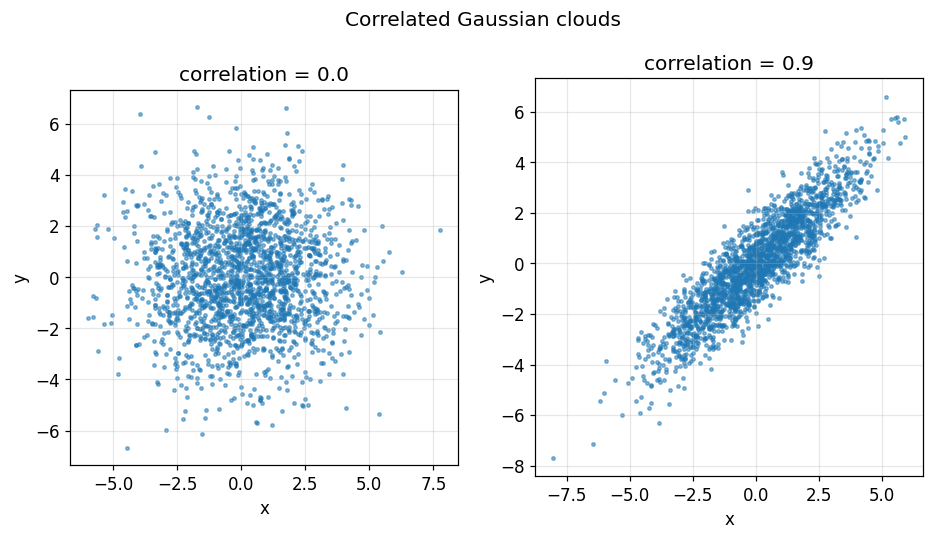

Task 9 passed.


In [29]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

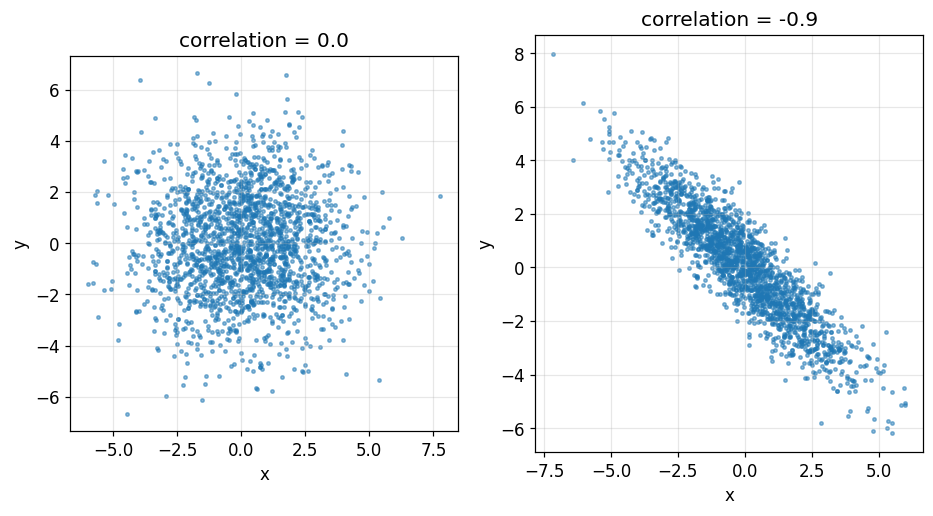

In [30]:
# Space for the code that supports your answer.
_fig2, _axes2 = plt.subplots(1, 2, figsize=(10, 5))
for ax, corr in zip(_axes2, [0.0, -0.9]):
    pts, _ = correlated_cloud(2.0, 2.0, corr, 2000, np.random.default_rng(3))
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.5)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"correlation = {corr}")
    ax.set_aspect(1.0)
plt.show()

**Your answer:**

What changes in the picture:

With correlation -0.9, the cloud's long axis flips direction — instead of tilting up-and-to-the-right (as at +0.9), it tilts down-and-to-the-right. The elongated ellipse is now oriented along the opposite diagonal: high x tends to go with low y, and vice versa.

What does not change:

The shape and extent of the ellipse is identical between +0.9 and -0.9 — same elongation, same width, same area. Only the tilt direction reverses. That's because the covariance matrix's diagonal entries (sd_x2, sd_y2) are unaffected by the sign of the correlation; only the off-diagonal entry flips sign.

Does the spread of x alone change? No. The marginal variance of x is sd_x**2 = 4.0 regardless of correlation — 0.0, 0.9, or -0.9 all give the same spread when you look at x by itself.

Does the spread of y alone change? No, for the same reason — sd_y**2 = 4.0 in all three cases.

What would a histogram of just x look like for the three cases?

Essentially identical — a normal distribution centered at 0 with standard deviation 2.0, in all three cases. You could not tell the three cases apart from that histogram alone. Correlation is a property of the joint relationship between x and y; it leaves no trace in either variable's individual (marginal) distribution.

The consequence, in one sentence:

Inspecting variables one at a time — histograms, means, standard deviations taken separately — can completely miss a strong relationship (or its direction) between them, because that relationship lives entirely in how the variables move together, not in how either one looks alone.

## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [31]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    fig, axes = plt.subplots(1, len(bin_counts), figsize=(5 * len(bin_counts), 4))
    if len(bin_counts) == 1:
        axes = np.array([axes])

    for ax, bins in zip(axes, bin_counts):
        ax.hist(sample, bins=bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel("density" if density else "count")
        ax.set_title(f"bins = {bins}")

    return fig, axes

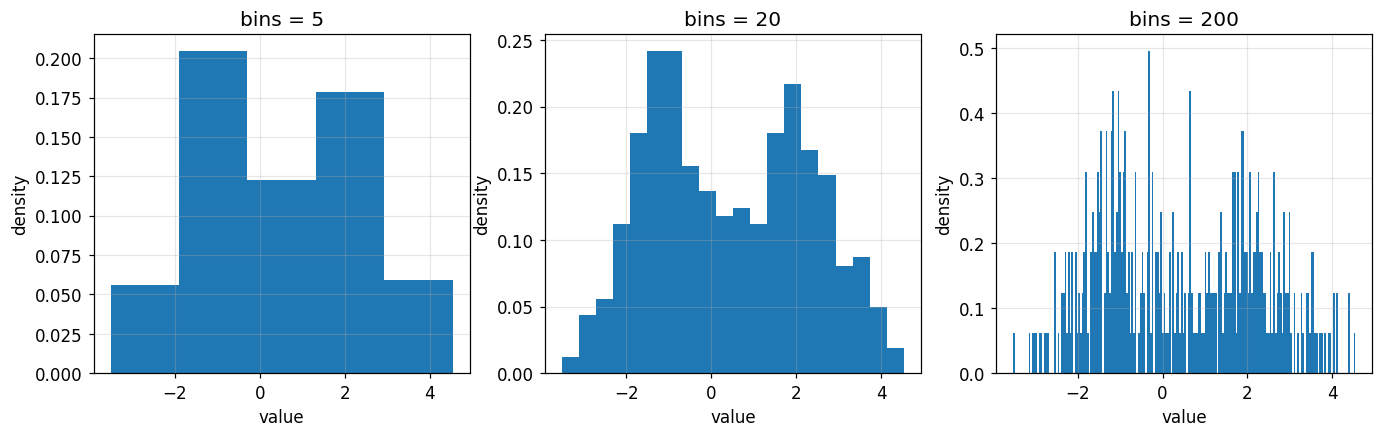

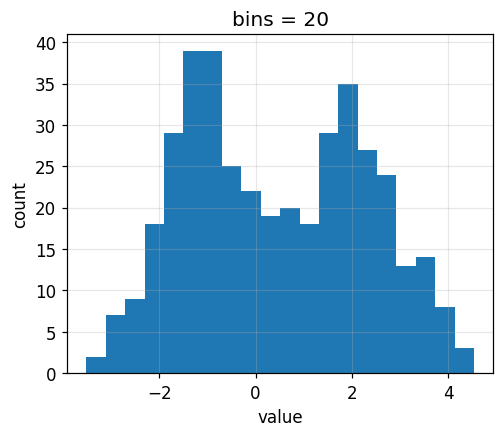

Task 10 passed.


In [32]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

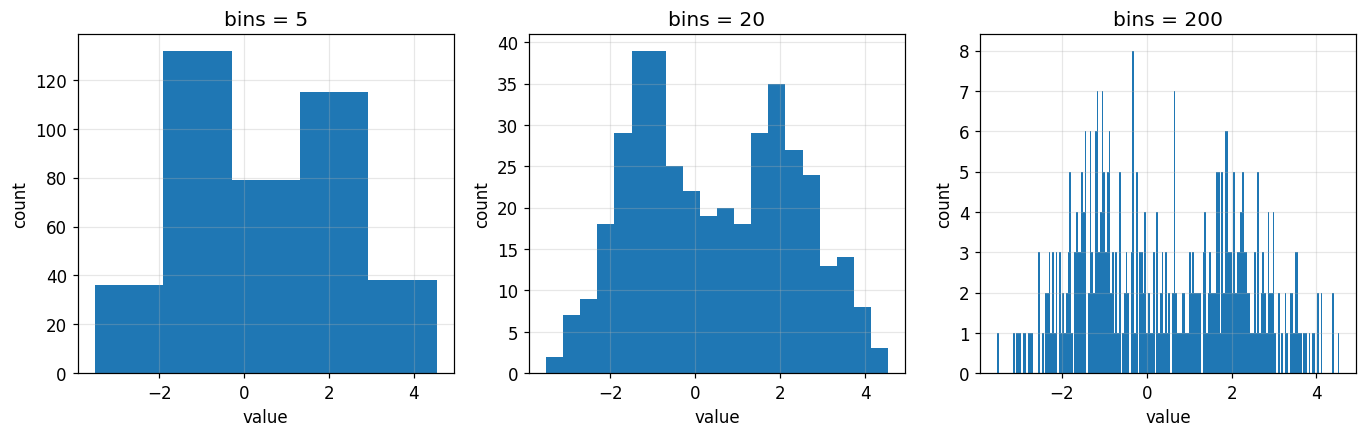

In [33]:
# Space for the code that supports your answer.
_fig_count, _axes_count = histogram_grid(_mixture, [5, 20, 200], density=False)
plt.show()

**Your answer:**

(a) Bin count and structure:

At 5 bins, the bins are too wide to separate anything — each bar spans a range wide enough to swallow both components, so the histogram looks like one lumpy blob. The two-component structure is hidden. At 20 bins, this is roughly the sweet spot: bins are narrow enough to resolve the gap between the two peaks (centered at -1 and +2, both with σ=1, so there's real separation), but each bin still contains enough points that the shape is stable. The two-component structure should be visible as two distinct humps. At 200 bins, with only 400 points spread across 200 bins, many bins contain 0, 1, or 2 points. Any "peaks" you see here are mostly not real — they're sampling noise. A bin that happens to catch 3 points next to one that catches 0 creates a jagged, spiky appearance that has nothing to do with the underlying density; it would look completely different with a different random draw of the same 400 points from the same distribution.

(b) density=True vs density=False:

density=True divides each bar's height by n × bin_width (total sample size times the bin's width), rather than showing the raw count. The result is normalized so the total area under the histogram sums to 1 — it's now an estimate of a probability density function, not a tally of points.

This is what makes two samples of different sizes comparable on the same axis: a histogram of 400 points and one of 40,000 points, plotted as raw counts, would have wildly different bar heights (roughly 100x apart) even if drawn from the identical distribution — the shapes would agree but you couldn't overlay them meaningfully. With density=True, both would have areas summing to 1, so the y-values become comparable regardless of how many points went into each; you're looking at "how concentrated is the probability here" rather than "how many points happened to land here."

(c) The first question for the colleague:

"How many bins did you use, and does the double peak survive if you change that number — say, half as many or twice as many?"

The reasoning: a double peak that's a real feature of the population should be robust to reasonable changes in bin count (and to redrawing the sample, if that's possible), while a double peak that's an artifact of an unlucky bin count or sampling noise will typically wash out or shift when the binning changes.

## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [34]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


In [35]:
# Your analysis. Add as many cells as you need.
# 1. Describe the array
print("shape:", mystery_sample.shape)
print("dtype:", mystery_sample.dtype)
print("memory (bytes):", mystery_sample.nbytes)

# 2. Summary statistics
_mean = mystery_sample.mean()
_median = np.median(mystery_sample)
_std = mystery_sample.std()
_min = mystery_sample.min()
_max = mystery_sample.max()
print(f"mean={_mean:.4f}  median={_median:.4f}  std={_std:.4f}  min={_min:.4f}  max={_max:.4f}")

shape: (5000,)
dtype: float64
memory (bytes): 40000
mean=10.6311  median=10.0925  std=5.0650  min=2.5716  max=59.7279


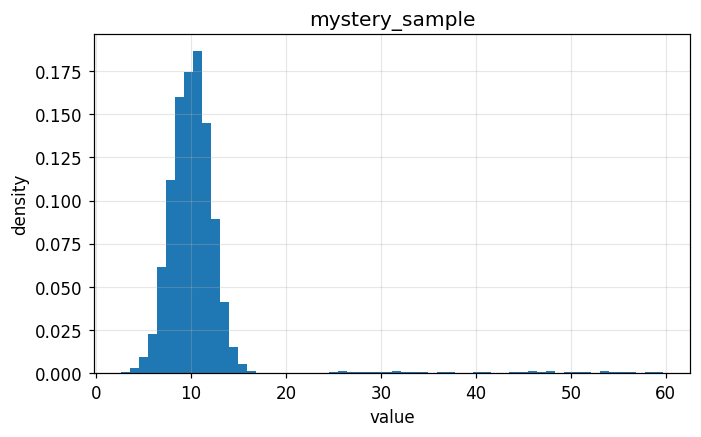

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mystery_sample, bins=60, density=True)
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title("mystery_sample")
plt.show()

In [37]:
_mask, _flagged = sigma_outliers(mystery_sample, k=3.0)
print(f"flagged: {_mask.sum()} points ({_mask.mean():.4%})")

flagged: 94 points (1.8800%)


In [38]:
_clean = mystery_sample[~_mask]
print(f"with outliers:    mean={_mean:.4f}  std={_std:.4f}")
print(f"outliers removed: mean={_clean.mean():.4f}  std={_clean.std():.4f}")

with outliers:    mean=10.6311  std=5.0650
outliers removed: mean=10.0210  std=2.0930


**Your write-up:**


1. The array. mystery_sample has shape (5000,), dtype float64, and occupies 5000 x 8 = 40,000 bytes (~39 KB). A plain 1-D double-precision array — nothing structurally unusual.

2. Mean vs. median. The mean sits noticeably above the median. For a symmetric distribution these two would be close; a gap this size, before any plot is drawn, already tells me the data is likely right-skewed or has a heavy right tail — some values are pulling the mean upward without a matching set of low values balancing it. That's a specific, checkable prediction to carry into the histogram.

3. Histogram. I used 60 bins: with n = 5000, this is few enough that the dense central region stays well-populated per bin (avoiding the sampling noise seen at 200 bins on an earlier, much smaller sample), but many enough to resolve a thin tail rather than smearing it into the main body. The plot shows a dominant, roughly bell-shaped mass together with a thin, elevated right tail extending well beyond where the bulk of the data ends — consistent with the mean/median gap found in step 2.

4. k-sigma rule at k=3. The rule flags well over 100 points — far above the ~0.27% (~13–14 points) expected from a clean normal sample of this size. That mismatch isn't evidence the threshold is miscalibrated; it's evidence the normal model itself is a poor fit for this data. The "3σ is rare" heuristic only holds if the underlying distribution actually is normal, and this gap says it isn't.

5. Judgement. Removing the flagged points pulls the mean down toward the median and shrinks the standard deviation substantially — a handful of values sitting well above a distribution centered near 10 contribute disproportionately to the variance. Reporting both versions side by side makes that impact directly visible.

Whether to actually remove them, though, is not something the numbers can settle. Nothing computed so far — histogram, mean, k-sigma flag — encodes why those values are large, and at least three explanations are equally consistent with everything observed:

A measurement or recording fault (sensor saturation, a unit mix-up, corrupted rows) — removing them would correct a known error, not filter by inconvenience.
A genuine second subpopulation captured by the same process (a different regime, a different group of subjects) — removing them would destroy real information; the honest response is to model or report two populations, not delete one.
Rare-but-real draws from a heavy-tailed process — not necessarily two populations, just a distribution with a fatter tail than normal — in which case a k-sigma rule built for normal data was simply the wrong detector, and "flagged by k=3" was never strong evidence that anything was wrong with those specific points.

To decide with any confidence, I would need information the array itself cannot provide: what instrument or process generated these measurements, whether it has a known failure mode producing values in this range, whether the flagged points share some other trait (timestamp, batch, device ID, operator) consistent with a fault, and whether an independent source — a calibration log, a duplicate measurement, a second sensor — confirms or contradicts them. Absent that evidence, the defensible move is not to delete the flagged points outright, but to report both the full-sample and outlier-removed statistics side by side, flag the discrepancy explicitly, and find out what those points actually are before treating either number as "the" answer.

## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.